<a href="https://colab.research.google.com/github/sampada-11/Data_Science_Lab/blob/main/exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.

--- Initial Data Exploration ---
First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0        

/tmp/ipykernel_7571/3482621639.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_7571/3482621639.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

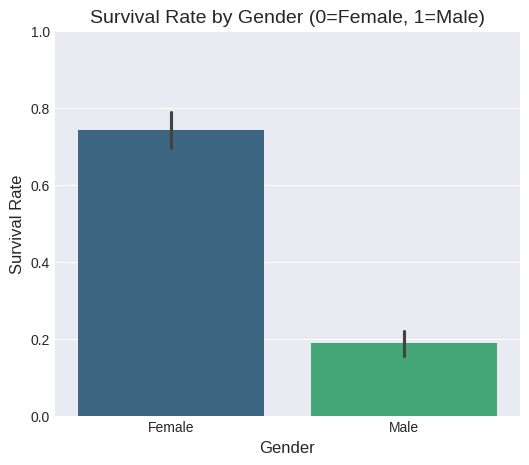

/tmp/ipykernel_7571/3482621639.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='magma')


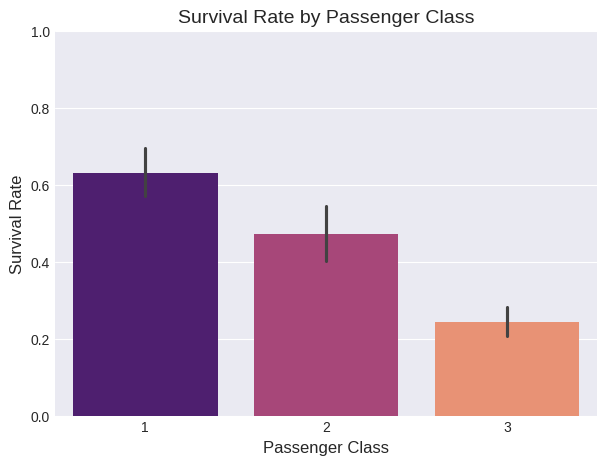

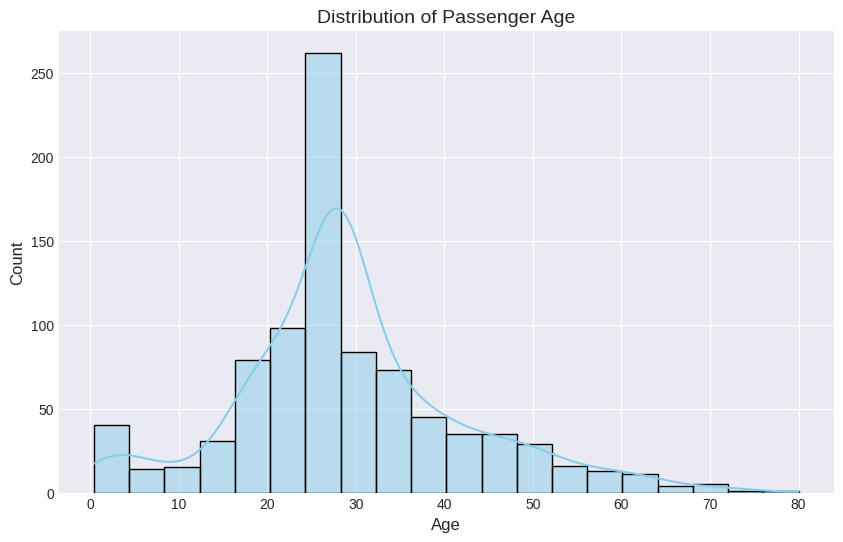

/tmp/ipykernel_7571/3482621639.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=df, palette='cividis', errorbar=None) # errorbar=None to hide confidence intervals for simplicity


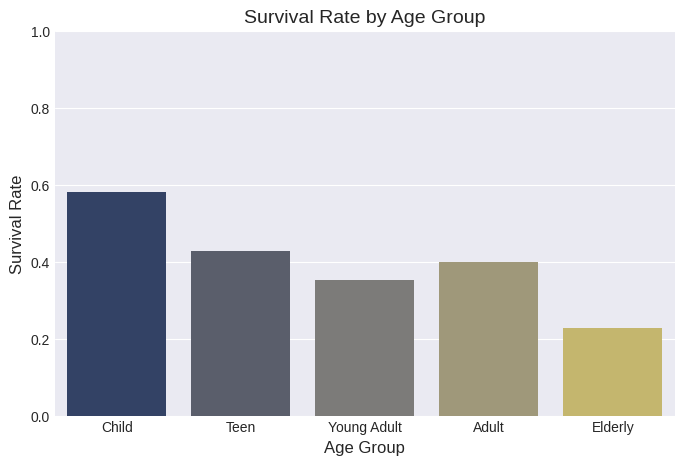

/tmp/ipykernel_7571/3482621639.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='plasma')


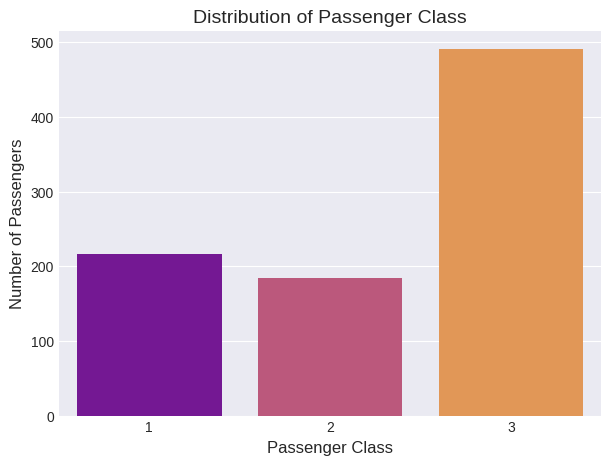


Data preprocessing and visualizations complete. Insights into demographics and survival trends are displayed above.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('/content/Titanic-Dataset.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Titanic-Dataset.csv' not found. Please ensure the file is in the correct path.")
    exit()

# --- 1. Initial Data Exploration ---
print("\n--- Initial Data Exploration ---")
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values before handling:")
print(df.isnull().sum())

# --- 2. Handle Missing Values ---
# Fill missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing 'Embarked' values with the most frequent value (mode)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Drop the 'Cabin' column due to a large number of missing values and potential irrelevance for this analysis
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

# --- 3. Data Preprocessing ---
# Convert 'Sex' to numerical (0 for female, 1 for male)
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# One-hot encode 'Embarked' for better representation, though not strictly necessary for simple plots
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# --- 4. Create Meaningful Visualizations ---
plt.style.use('seaborn-v0_8-darkgrid') # Set a nice style for plots

# Visualization 1: Survival Rate by Gender
plt.figure(figsize=(6, 5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender (0=Female, 1=Male)', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.xticks([0, 1], ['Female', 'Male'])
plt.ylim(0, 1)
plt.show()

# Visualization 2: Survival Rate by Passenger Class
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='magma')
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.ylim(0, 1)
plt.show()

# Visualization 3: Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Passenger Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# Visualization 4: Survival Rate by Age Group
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 80], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])
plt.figure(figsize=(8, 5))
sns.barplot(x='AgeGroup', y='Survived', data=df, palette='cividis', errorbar=None) # errorbar=None to hide confidence intervals for simplicity
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.ylim(0, 1)
plt.show()

# Visualization 5: Distribution of Passenger Class
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', data=df, palette='plasma')
plt.title('Distribution of Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

print("\nData preprocessing and visualizations complete. Insights into demographics and survival trends are displayed above.")